# Quick test of optimizer_2 (multi-start SLSQP)

In [60]:
# Use local systemdynamics package
import sys, os, importlib
sys.path.insert(0, os.path.abspath('..'))  # add project root
sys.path.insert(0, os.path.abspath('.'))  # add tutorials folder

# Reload optimizer_2 and core modules
import systemdynamics.optimizer_2 as opt2
import importlib
importlib.reload(opt2)
from systemdynamics.cld import Extract
from systemdynamics.sdm import SDM
import numpy as np

In [61]:
import importlib
import systemdynamics.optimizer_2 as opt2
importlib.reload(opt2)
optimizer = opt2.SDMOptimizer(sdm)

In [62]:
# Debug: show a sample row from the optimizer output before DataFrame construction
import inspect
print(inspect.getsource(optimizer.optimize_across_parameter_samples))

    def optimize_across_parameter_samples(
        self,
        costs: Union[np.ndarray, List[float]],
        variable_of_interest: Optional[str] = None,
        *,
        n_parameter_samples: Optional[int] = None,
        # optimization parameters forwarded
        budget: float = 1.0,
        maximize: bool = True,
        n_starts: Optional[int] = None,
        seed: Optional[int] = None,
        sobol_power_of_two: bool = True,
        threshold_atol: float = 0.01,
        threshold_rtol: float = 0.0,
        y_dedupe_tol: float = 1e-6,
        slsqp_maxiter: int = 50,
        slsqp_ftol: float = 1e-3,
        penalty_value: float = 1e30,
        debug: bool = False,
        algorithm: str = "multistart_slsqp",
        # mapping / output control
        store_parameter_samples: bool = True,
        return_parameter_samples: bool = False,
        show_progress: bool = True,
    ) -> Union[pd.DataFrame, Tuple[pd.DataFrame, List[Dict[str, Any]]]]:
        """
        Optimize acros

In [63]:
# Load Alzheimer settings (same as tutorial)
current_path = os.getcwd()
file_name = 'Alzheimer'
file_path = os.path.join(current_path, f'{file_name}.xlsx')
extract = Extract(file_path)
s = extract.extract_settings()

# Light simulation settings for fast test
s.seed = 12345
s.N = 11  # small sample for quick run
s.t_end = 10
s.time_unit = 'quarter-years'
s.parameter_value_aux = 0.1
s.parameter_value_stocks = 0.1

sdm = SDM(s)

Variable of interest: Cognitive functioning
with 4 intervention variables
Removed 2.0 incoming links for constant Diabetes
Removed 4.0 incoming links for constant Dyslipidaemia
Removed 6.0 incoming links for constant Social relationships
Removed 1.0 incoming links for constant Hearing loss
Removed 2.0 incoming links for constant Smoking
Removed 1.0 incoming links for constant Excessive alcohol use
Removed 4.0 incoming links for constant Motor function

75 feedback loops of maximum length 5
All loops have at least one stock
Custom equation for 'Neuroinflammation': (1+tanh(-($+#1*Systemic inflammation*Systemic inflammation - #3*Healthy dietary patterns+#7*Systemic inflammation+#4*Oxidative stress + #5* Amyloid beta burden + #6*Head trauma)))/2
  Variables used: {'Healthy dietary patterns', 'Systemic inflammation', 'Amyloid beta burden', 'Oxidative stress', 'Head trauma'}
  Parameters (#): 6
  Intervention ($): Yes - intervention applied within equation

Solving an SDM with interaction te

In [ ]:
# Run a single optimization with the packaged optimizer_2 (current API)
optimizer = opt2.SDMOptimizer(sdm)
params = sdm.sample_model_parameters()
costs = [1.0] * len(s.intervention_variables)
voi = s.variable_of_interest[0]

# Pass optimizer hyperparameters for higher precision
result = optimizer.optimize_intervention_intensities(
    params=params,
    costs=costs,
    variable_of_interest=voi,
    maximize=True,
    n_starts=16,  # increased number of starts
    slsqp_maxiter=300,  # increased max iterations for each SLSQP local optimization run
    slsqp_ftol=1e-9,    # tighter function tolerance for convergence of objective function
)

print('Success:', result['success'])
print('Best effect size:', result['best_effect_size'])
print('Equilibria found:', result['n_equilibria'])

Success: True
Best effect size: 0.5353421108673547
Equilibria found: 5


In [93]:
# Run optimization across all parameter samples
opt_df = optimizer.optimize_across_parameter_samples(
    costs=costs,
    variable_of_interest=voi,
    maximize=True,
    n_starts=8,  # Sobol samples per parameter set
)

print(f"Optimization completed: {len(opt_df)} rows")
print(f"Unique parameter samples: {opt_df['sample_idx'].nunique()}")
print("Columns:", list(opt_df.columns))
if 'success' in opt_df.columns:
    print(f"Success rate: {opt_df.groupby('sample_idx')['success'].max().mean()*100:.1f}%")
else:
    print("No 'success' column found in results!")

opt_df.head()

Optimizing across parameter samples (multistart_slsqp): 100%|██████████| 11/11 [00:20<00:00,  1.88s/it]


Optimization completed: 11 rows
Unique parameter samples: 11
Columns: ['sample_idx', 'equilibrium_idx', 'voi_effect_size', 'total_cost', 'n_equilibria', 'success', 'param_Cognitive functioning__Intercept', 'param_Cognitive functioning__Brain atrophy', 'param_Cognitive functioning__Neuronal dysfunction', 'param_Cognitive functioning__Depressive symptoms', 'param_Cognitive functioning__Sleep quality', 'param_Cognitive functioning__Brain perfusion', 'param_Cognitive functioning__Neuronal connectivity', 'param_Cognitive functioning__Hearing loss', 'param_Brain atrophy__Intercept', 'param_Brain atrophy__Neuronal dysfunction', 'param_Neuronal dysfunction__Intercept', 'param_Neuronal dysfunction__Cerebral endothelial dysfunction', 'param_Neuronal dysfunction__Amyloid beta burden', 'param_Neuronal dysfunction__Tau burden', 'param_Neuronal dysfunction__Healthy dietary patterns', 'param_Neuronal dysfunction__Brain perfusion', 'param_Neuronal dysfunction__Oxidative stress', 'param_Neuronal dysfun

,sample_idx,equilibrium_idx,voi_effect_size,total_cost,n_equilibria,success,param_Cognitive functioning__Intercept,param_Cognitive functioning__Brain atrophy,param_Cognitive functioning__Neuronal dysfunction,param_Cognitive functioning__Depressive symptoms,...,param_Neuroinflammation____eq_params_Neuroinflammation____5,param_Neuronal connectivity__Intercept,param_Neuronal connectivity__Neuronal dysfunction,param_Neuronal connectivity__Engagement in cognitively demanding tasks,param_Neuronal connectivity__Physical activity,param_Neuronal connectivity__Sleep quality,intensity_Depressive symptoms,intensity_Obesity,intensity_Physical activity,intensity_Neuroinflammation
0,0,0,0.285852,0.999992,1,True,0,-0.043681,-0.083097,-0.042923,...,0.022939,0,-0.011605,0.012580,0.083897,0.026908,0.748985,0.000000e+00,2.510066e-01,2.081668e-17
1,1,0,0.520344,0.999955,1,True,0,-0.088251,-0.020992,-0.064054,...,0.066019,0,-0.064648,0.019278,0.012831,0.051024,0.748266,2.775558e-17,5.222518e-02,1.994638e-01
2,2,0,0.659876,0.999819,1,True,0,-0.041950,-0.027370,-0.080493,...,0.046223,0,-0.047109,0.069450,0.078599,0.086934,0.783963,2.158563e-01,0.000000e+00,0.000000e+00
3,3,0,0.992062,1.000000,1,True,0,-0.054343,-0.017034,-0.093611,...,0.074702,0,-0.027166,0.052956,0.078981,0.040650,1.000000,0.000000e+00,4.163336e-16,2.775558e-17
4,4,0,0.157864,0.999821,1,True,0,-0.011047,-0.072658,-0.030411,...,0.097563,0,-0.014539,0.085321,0.082123,0.084391,0.539080,1.103577e-02,4.497050e-01,0.000000e+00


Detected intensity columns: ['intensity_Depressive symptoms', 'intensity_Obesity', 'intensity_Physical activity', 'intensity_Neuroinflammation']
Detected parameter columns: ['param_Cognitive functioning__Intercept', 'param_Cognitive functioning__Brain atrophy', 'param_Cognitive functioning__Neuronal dysfunction', 'param_Cognitive functioning__Depressive symptoms', 'param_Cognitive functioning__Sleep quality', 'param_Cognitive functioning__Brain perfusion', 'param_Cognitive functioning__Neuronal connectivity', 'param_Cognitive functioning__Hearing loss', 'param_Brain atrophy__Intercept', 'param_Brain atrophy__Neuronal dysfunction', 'param_Neuronal dysfunction__Intercept', 'param_Neuronal dysfunction__Cerebral endothelial dysfunction', 'param_Neuronal dysfunction__Amyloid beta burden', 'param_Neuronal dysfunction__Tau burden', 'param_Neuronal dysfunction__Healthy dietary patterns', 'param_Neuronal dysfunction__Brain perfusion', 'param_Neuronal dysfunction__Oxidative stress', 'param_Neuro

C:\Users\vvvas\AppData\Local\Temp\ipykernel_11460\255998675.py:54: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


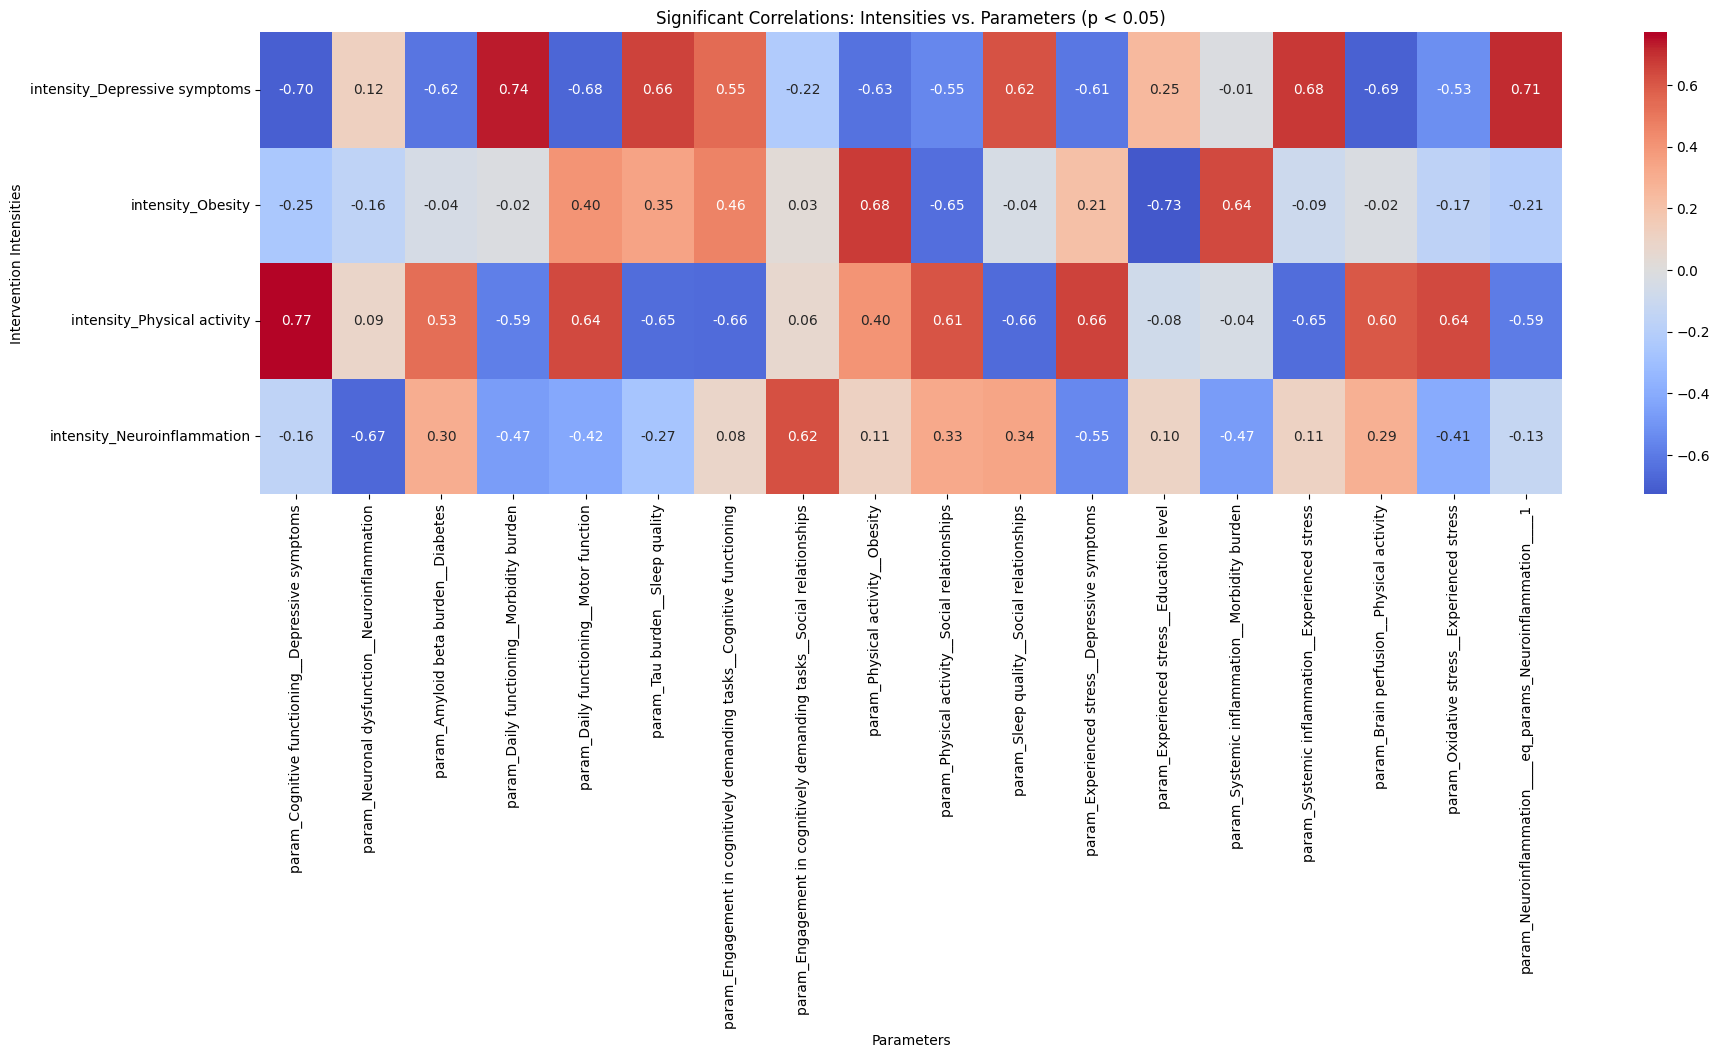

In [94]:
# Visualize only significant, non-NaN cross-correlations between intervention intensities and parameters
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Select columns for intensities and parameters (flattened)
def get_intensity_and_param_columns(df):
    intensity_cols = [col for col in df.columns if col.startswith('intensity_')]
    param_cols = [col for col in df.columns if col.startswith('param_') and not col.endswith('_type')]
    return intensity_cols, param_cols

intensity_cols, param_cols = get_intensity_and_param_columns(opt_df)

print(f"Detected intensity columns: {intensity_cols}")
print(f"Detected parameter columns: {param_cols}")

# Compute correlation and p-value matrices
corr_matrix = np.full((len(intensity_cols), len(param_cols)), np.nan)
pval_matrix = np.full((len(intensity_cols), len(param_cols)), np.nan)

for i, int_col in enumerate(intensity_cols):
    for j, par_col in enumerate(param_cols):
        x = opt_df[int_col]
        y = opt_df[par_col]
        mask = x.notna() & y.notna()
        if mask.sum() > 2 and np.nanstd(y[mask]) > 0 and np.nanstd(x[mask]) > 0:
            r, p = pearsonr(x[mask], y[mask])
            corr_matrix[i, j] = r
            pval_matrix[i, j] = p

# Mask for significant and non-NaN correlations (e.g., p < 0.05)
sig_mask = (pval_matrix < 0.05) & ~np.isnan(corr_matrix)

# Filter out columns (parameters) with all NaN or all non-significant
keep_param = np.any(sig_mask, axis=0)
keep_intensity = np.any(sig_mask, axis=1)

filtered_corr = corr_matrix[np.ix_(keep_intensity, keep_param)]
filtered_pval = pval_matrix[np.ix_(keep_intensity, keep_param)]
filtered_intensity = [intensity_cols[i] for i, keep in enumerate(keep_intensity) if keep]
filtered_param = [param_cols[j] for j, keep in enumerate(keep_param) if keep]

if filtered_corr.size == 0:
    print('No significant correlations found.')
else:
    plt.figure(figsize=(max(8, len(filtered_param) + 3), max(6, len(filtered_intensity) + 2)))
    sns.heatmap(filtered_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                xticklabels=filtered_param, yticklabels=filtered_intensity,
                mask=np.isnan(filtered_corr))
    plt.title('Significant Correlations: Intensities vs. Parameters (p < 0.05)')
    plt.xlabel('Parameters')
    plt.ylabel('Intervention Intensities')
    plt.tight_layout()
    plt.show()

Plotting top 2 interventions by allocation:
  1. Depressive symptoms: mean = 0.7243
  2. Physical activity: mean = 0.2334


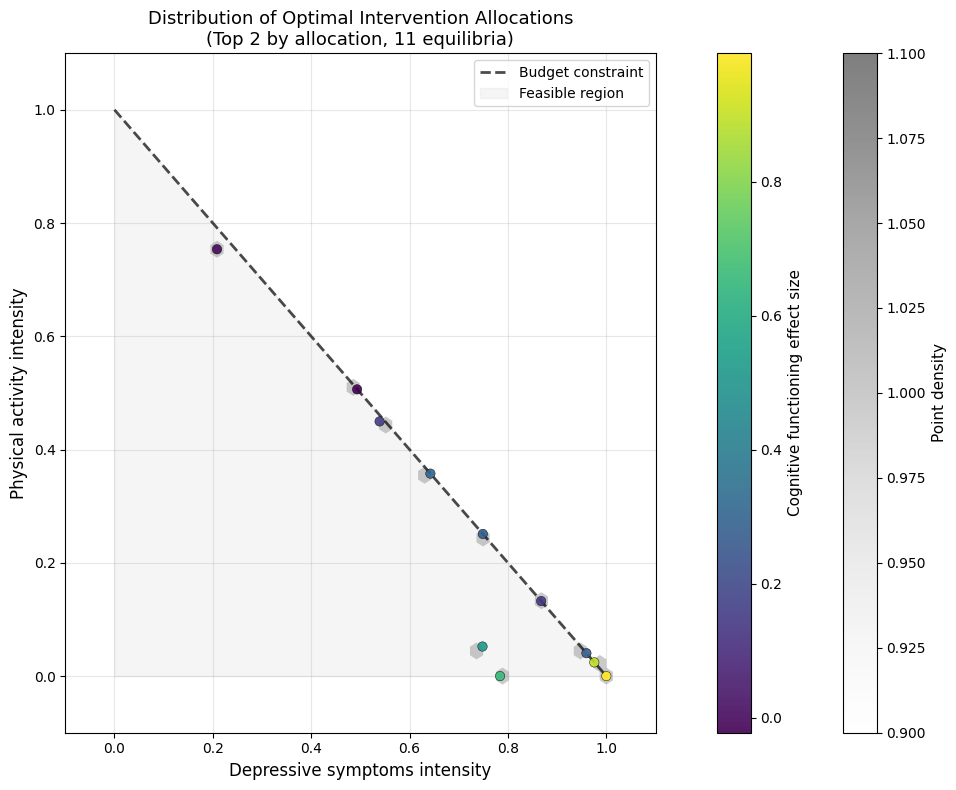


Optimization results summary (11 equilibria):
  Depressive symptoms: mean=0.724, std=0.230, range=[0.208, 1.000]
  Physical activity: mean=0.233, std=0.241, range=[0.000, 0.754]


In [95]:
# Plot distribution of optimal intensities in 2D simplex (top 2 interventions by mean allocation)
import matplotlib.pyplot as plt
import numpy as np

# Find interventions sorted by mean allocation (highest first)
mean_allocations_single = {}
for var in s.intervention_variables:
    col = f'intensity_{var}'
    mean_allocations_single[var] = opt_df[col].mean()

sorted_interventions = sorted(mean_allocations_single.items(), key=lambda x: x[1], reverse=True)
int_var_1 = sorted_interventions[0][0]  # Highest allocation
int_var_2 = sorted_interventions[1][0]  # Second highest

print(f"Plotting top 2 interventions by allocation:")
print(f"  1. {int_var_1}: mean = {mean_allocations_single[int_var_1]:.4f}")
print(f"  2. {int_var_2}: mean = {mean_allocations_single[int_var_2]:.4f}")

# Get cost indices for these variables
cost_1 = costs[s.intervention_variables.index(int_var_1)]
cost_2 = costs[s.intervention_variables.index(int_var_2)]

# Extract intensities from optimization results
x = opt_df[f'intensity_{int_var_1}'].values
y = opt_df[f'intensity_{int_var_2}'].values
effects = opt_df['voi_effect_size'].values

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the feasible region boundary
max_x = 1.0 / cost_1
max_y = 1.0 / cost_2
x_boundary = np.linspace(0, max_x, 100)
y_boundary = (1.0 - x_boundary * cost_1) / cost_2
y_boundary = np.maximum(y_boundary, 0)
ax.plot(x_boundary, y_boundary, 'k--', linewidth=2, label='Budget constraint', alpha=0.7, zorder=2)
ax.fill_between(x_boundary, 0, y_boundary, alpha=0.08, color='gray', label='Feasible region', zorder=1)

# Density layer: hexbin counts to show clustering (grayscale with dark = high density)
hb = ax.hexbin(x, y, gridsize=30, cmap='Greys', mincnt=1, linewidths=0.1, alpha=0.5, zorder=1)
cbar_density = plt.colorbar(hb, ax=ax, pad=0.012)
cbar_density.set_label('Point density', fontsize=11)

# Scatter plot colored by effect size
scatter = ax.scatter(x, y, c=effects, cmap='viridis', s=46, alpha=0.9,
                     edgecolors='black', linewidth=0.35, zorder=3)
cbar_effect = plt.colorbar(scatter, ax=ax, pad=0.08)
cbar_effect.set_label(f'{voi} effect size', fontsize=11)

ax.set_xlabel(f'{int_var_1} intensity', fontsize=12)
ax.set_ylabel(f'{int_var_2} intensity', fontsize=12)
ax.set_title(f'Distribution of Optimal Intervention Allocations\n(Top 2 by allocation, {len(opt_df)} equilibria)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Set axis limits based on data with some margin
margin_x = max_x * 0.1
margin_y = max_y * 0.1
ax.set_xlim(left=-margin_x, right=max_x + margin_x)
ax.set_ylim(bottom=-margin_y, top=max_y + margin_y)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nOptimization results summary ({len(opt_df)} equilibria):")
print(f"  {int_var_1}: mean={x.mean():.3f}, std={x.std():.3f}, range=[{x.min():.3f}, {x.max():.3f}]")
print(f"  {int_var_2}: mean={y.mean():.3f}, std={y.std():.3f}, range=[{y.min():.3f}, {y.max():.3f}]")